In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
import numpy as np

FLOOR_FILES = {
    1:     'Floor Plans/floor1.json',
    3:     'Floor Plans/floor3.json',
    4:     'Floor Plans/floor4 (2).json',
    5:     'Floor Plans/floor5.json',
    '6-9': 'Floor Plans/floor6-9.json',
}

floors = {}
for key, path in FLOOR_FILES.items():
    with open(path) as f:
        floors[key] = json.load(f)
    print(f'Floor {key}: {len(floors[key]["rooms"])} rooms loaded')

Floor 1: 125 rooms loaded
Floor 3: 148 rooms loaded
Floor 4: 107 rooms loaded
Floor 5: 77 rooms loaded
Floor 6-9: 79 rooms loaded


## 1 · Setup & Data Loading

All floor plan data is stored in the `Floor Plans/` directory as JSON files.  
Floors 6–9 were originally combined in one file and have been split into individual planes.

# Science Center Floor Plan Explorer
**Harvard Science Center — Indoor Navigation & Spatial Analysis**

---

## Overview

This notebook visualises the annotated floor plans of the **Harvard Science Center** building.  
Each floor is stored as a structured JSON graph where **rooms** are polygonal nodes and **doors / corridors** are connection edges.

### Building floors covered

| Floor | Label | Notable spaces |
|-------|-------|----------------|
| 1 | Ground floor | Cabot Library, Clover, Lecture Halls A–D |
| 3 | 3rd floor | Offices 300s, Classrooms |
| 4 | 4th floor | Math Lounge, Seminar rooms 400s |
| 5 | 5th floor | Research offices 500s |
| 6 | 6th floor | Offices 600s |
| 7 | 7th floor | Offices 700s |
| 8 | 8th floor | Offices / Classroom 800s |
| 9 | 9th floor | Harvard Telescope Club, Offices 900s |

### Naming convention
- **Classrooms & offices** → `R{room number}` (e.g. `R322`, `R400A`)  
- **Functional spaces** → descriptive name (e.g. *Cabot Library*, *Courtyard*)  
- **Doors & connections** → hidden (navigation graph edges, not rendered)  
- **Stairwells** → diagonal hatch, no label  
- **Elevators** → yellow fill with an × cross, no label

---

In [2]:
PASTEL = {
    'office':     '#B5D5E8',
    'classroom':  '#C8E6C9',
    'library':    '#E8D5B7',
    'lecture':    '#D7C8E8',
    'stairwell':  '#ECECEC',
    'elevator':   '#FFF9C4',
    'corridor':   '#F0F0F0',
    'entrance':   '#FFD6E0',
    'other':      '#E0E8D8',
    'door':       '#FFFFFF',
    'connection': '#FFFFFF',
}
DEFAULT_COLOR = '#F0F0F0'
DOOR_TYPES    = {'door', 'connection'}
LABEL_SIZE    = 5


def draw_floor(floor_data, title):
    rooms = floor_data['rooms']

    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('#FAFAFA')

    seen_types = set()

    for room in rooms:
        pts = room.get('polygon', [])
        if not pts:
            continue
        pts = np.array(pts, dtype=float)
        t       = room.get('type', 'other')
        color   = PASTEL.get(t, DEFAULT_COLOR)
        is_door = t in DOOR_TYPES

        # Polygon fill — stairwells get diagonal hatching
        hatch = '////' if t == 'stairwell' else None
        patch = MplPolygon(
            pts, closed=True,
            fc=color,
            ec='#AAAAAA' if is_door else '#888888',
            lw=0.3 if is_door else 0.6,
            alpha=0.0 if is_door else 0.85,
            hatch=hatch,
            zorder=1 if is_door else 2,
        )
        ax.add_patch(patch)

        if not is_door:
            seen_types.add(t)

        # Elevator: draw an X cross in the center
        if t == 'elevator':
            la = room.get('labelAnchor', {})
            cx = la.get('x', pts[:, 0].mean())
            cy = la.get('y', pts[:, 1].mean())
            r  = min(pts[:, 0].max() - pts[:, 0].min(),
                     pts[:, 1].max() - pts[:, 1].min()) * 0.3
            ax.plot([cx - r, cx + r], [cy - r, cy + r], color='#555555', lw=1.2, zorder=4)
            ax.plot([cx - r, cx + r], [cy + r, cy - r], color='#555555', lw=1.2, zorder=4)

        # Labels: visible for everything except doors, stairwells, elevators
        if room.get('showLabel', True) and t not in (DOOR_TYPES | {'stairwell', 'elevator'}):
            la = room.get('labelAnchor', {})
            cx = la.get('x', pts[:, 0].mean())
            cy = la.get('y', pts[:, 1].mean())
            ax.text(cx, cy, room['name'], ha='center', va='center',
                    fontsize=LABEL_SIZE, color='#333333', clip_on=True, zorder=3)

    ax.autoscale()
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=6)

    handles = [
        mpatches.Patch(facecolor=PASTEL.get(t, DEFAULT_COLOR),
                       edgecolor='#888888',
                       hatch='////' if t == 'stairwell' else None,
                       label=t.capitalize())
        for t in sorted(seen_types) if t not in DOOR_TYPES
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=6, framealpha=0.8)

    plt.tight_layout()
    plt.show()

## 2 · Colour Palette & Rendering Engine

A **pastel palette** is used to distinguish room types at a glance:

| Type | Colour | Description |
|------|--------|-------------|
| Office | ![#B5D5E8](https://via.placeholder.com/12/B5D5E8/B5D5E8.png) `#B5D5E8` | Pastel blue |
| Classroom | ![#C8E6C9](https://via.placeholder.com/12/C8E6C9/C8E6C9.png) `#C8E6C9` | Pastel green |
| Library | `#E8D5B7` | Pastel peach |
| Lecture hall | `#D7C8E8` | Pastel lavender |
| Entrance | `#FFD6E0` | Pastel rose |
| Other / Corridor | `#E0E8D8` / `#F0F0F0` | Pastel sage / near-white |

Special rendering rules:
- **Stairwells** → grey fill with `////` diagonal hatch pattern  
- **Elevators** → pastel yellow fill with a drawn × cross  
- **Doors/connections** → fully transparent (α = 0), labels suppressed

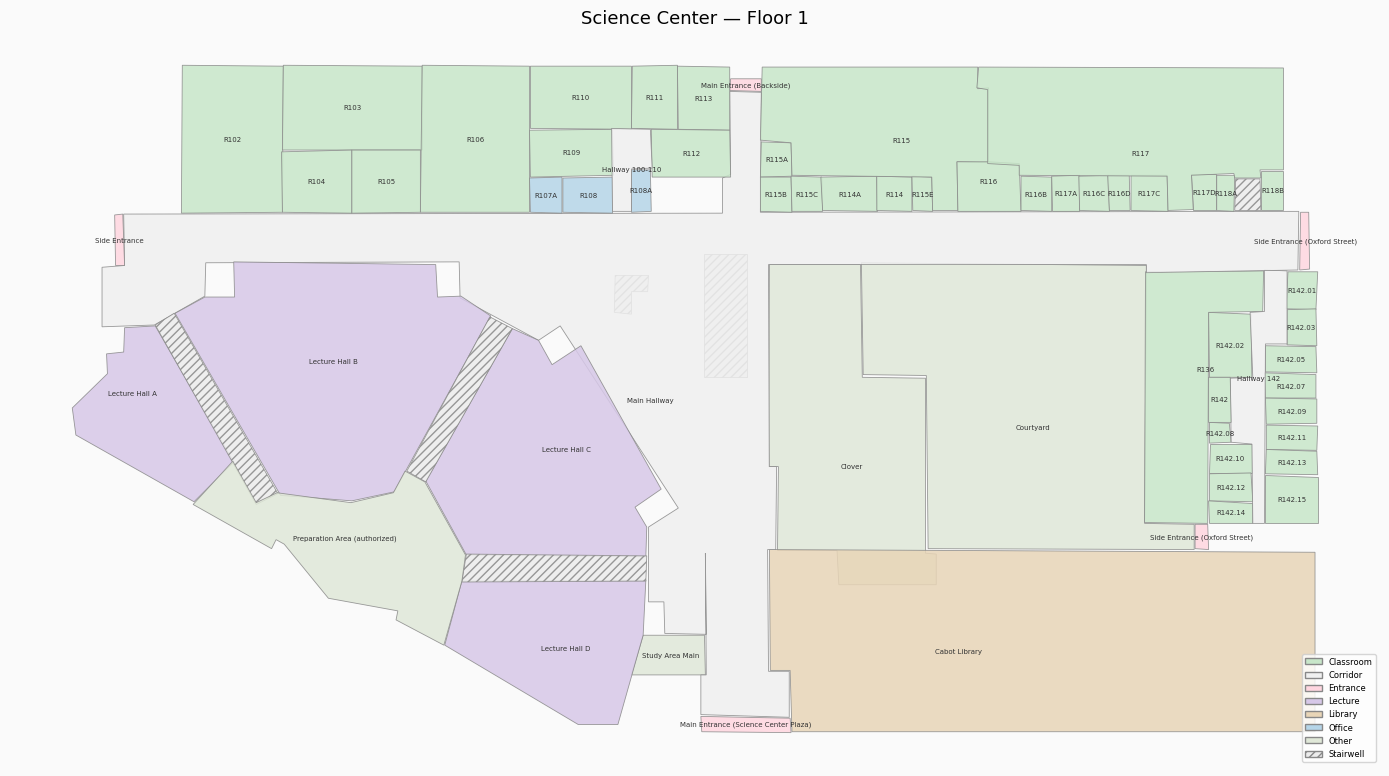

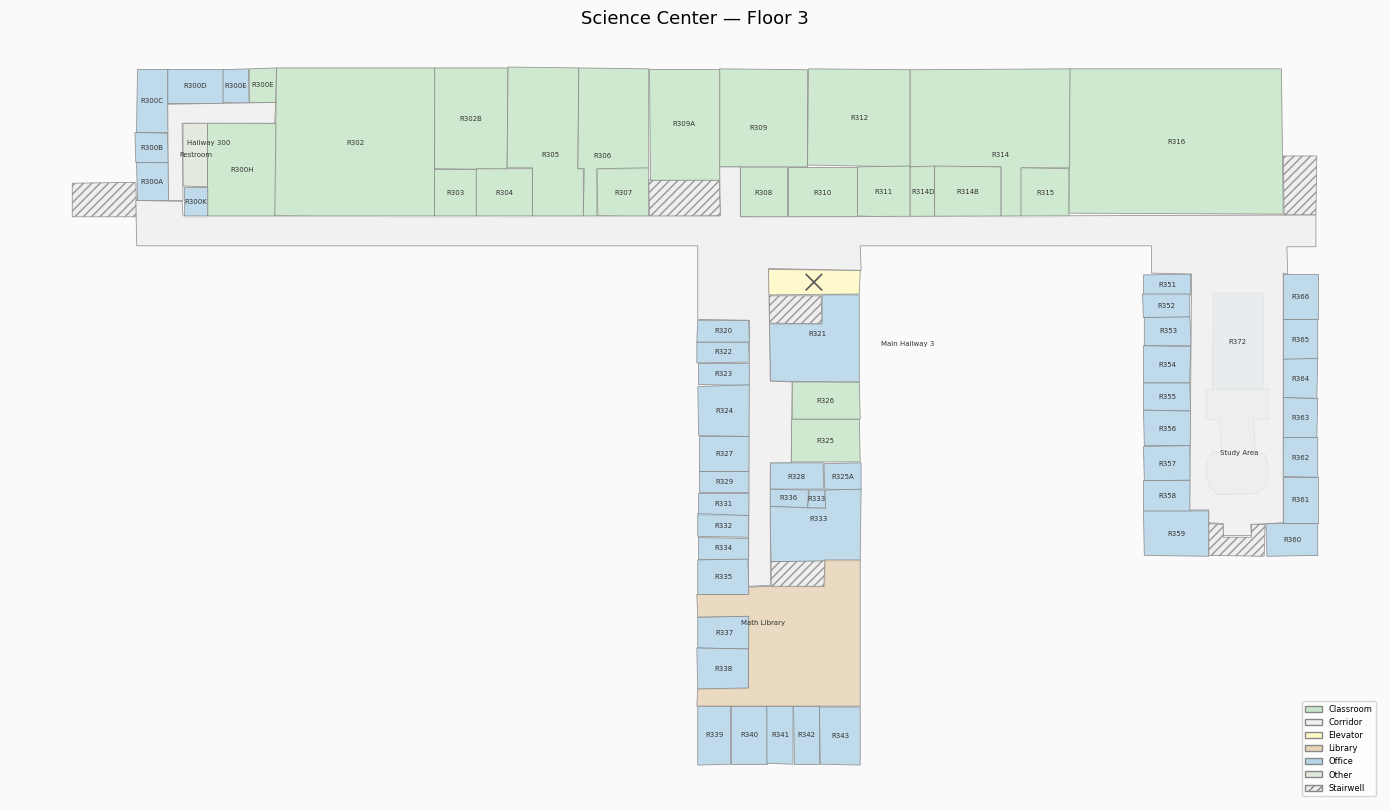

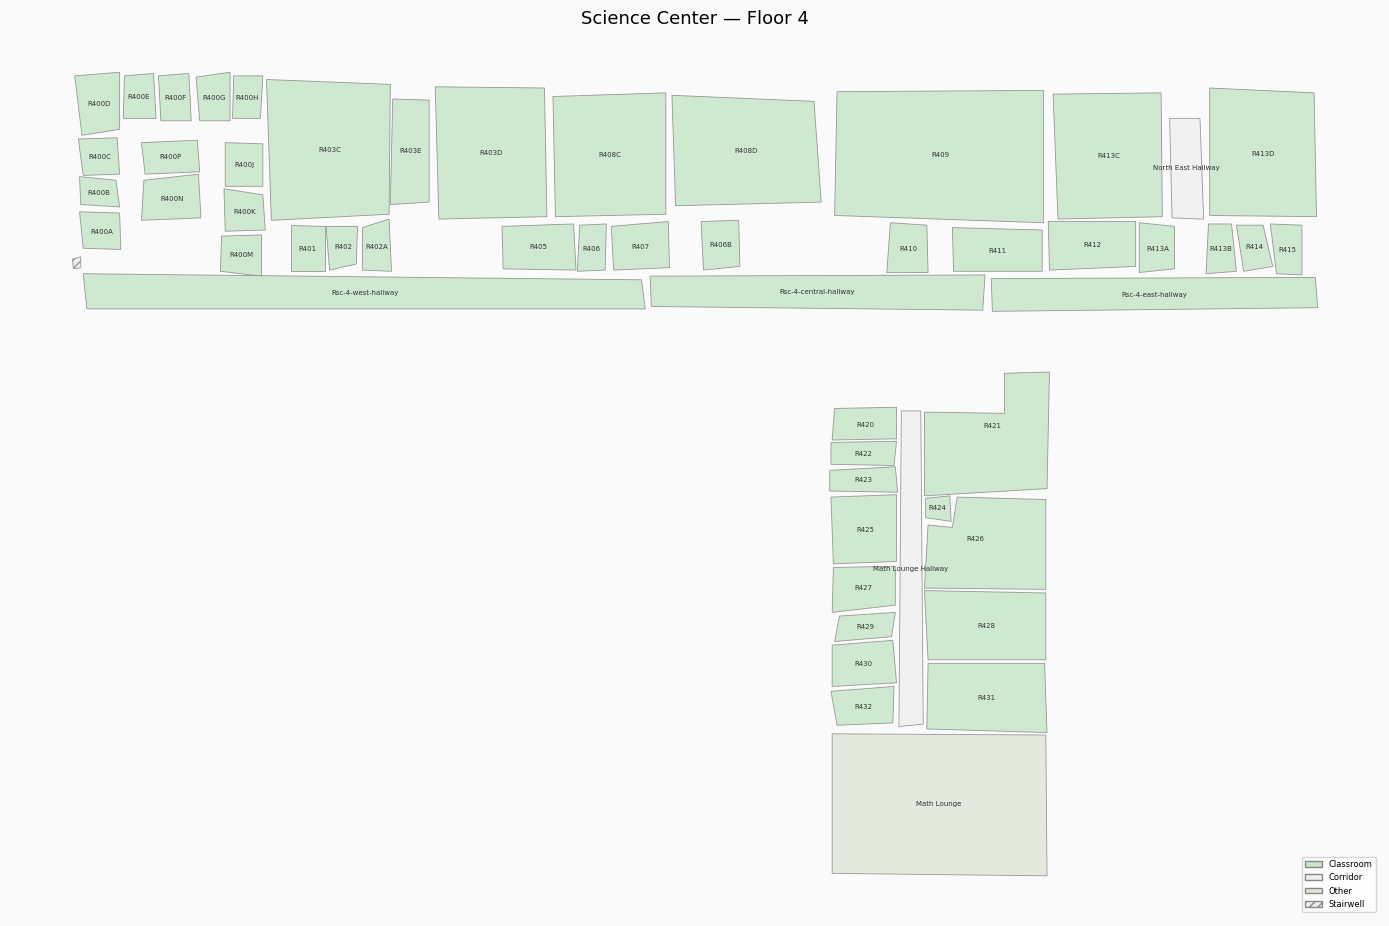

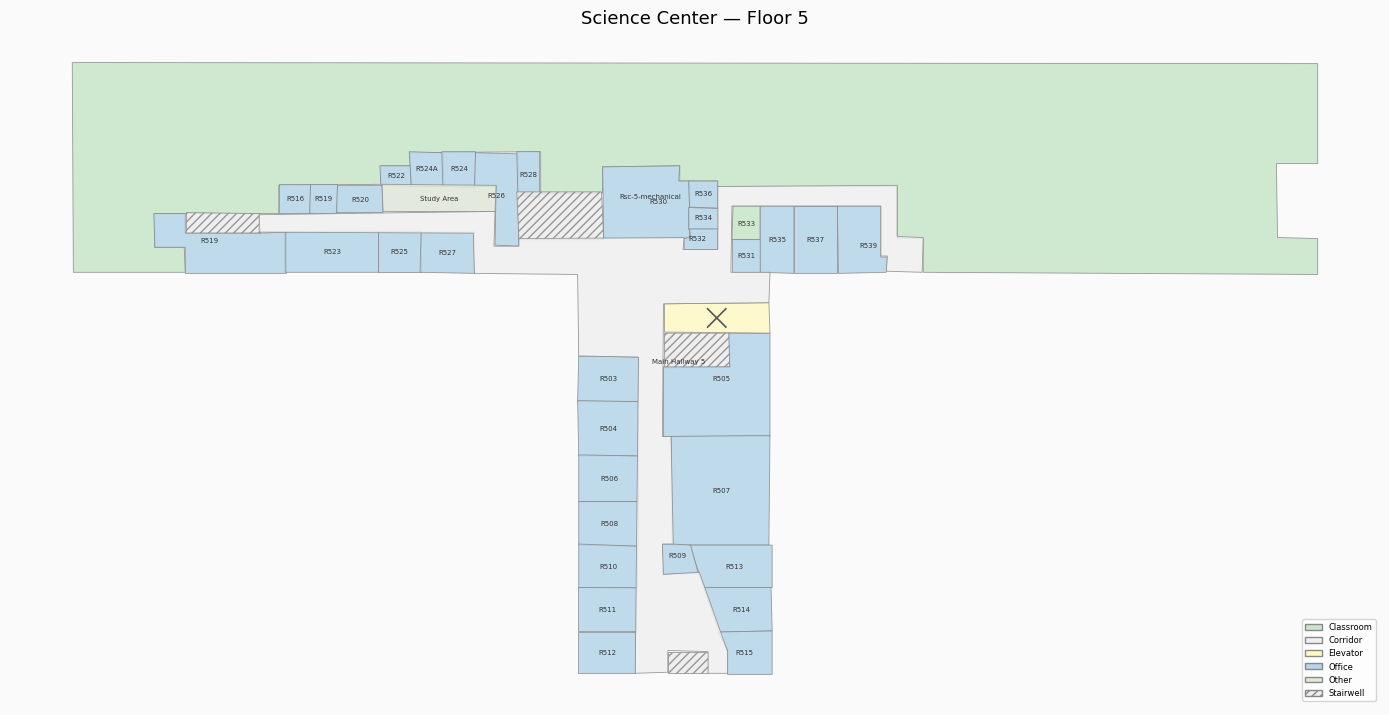

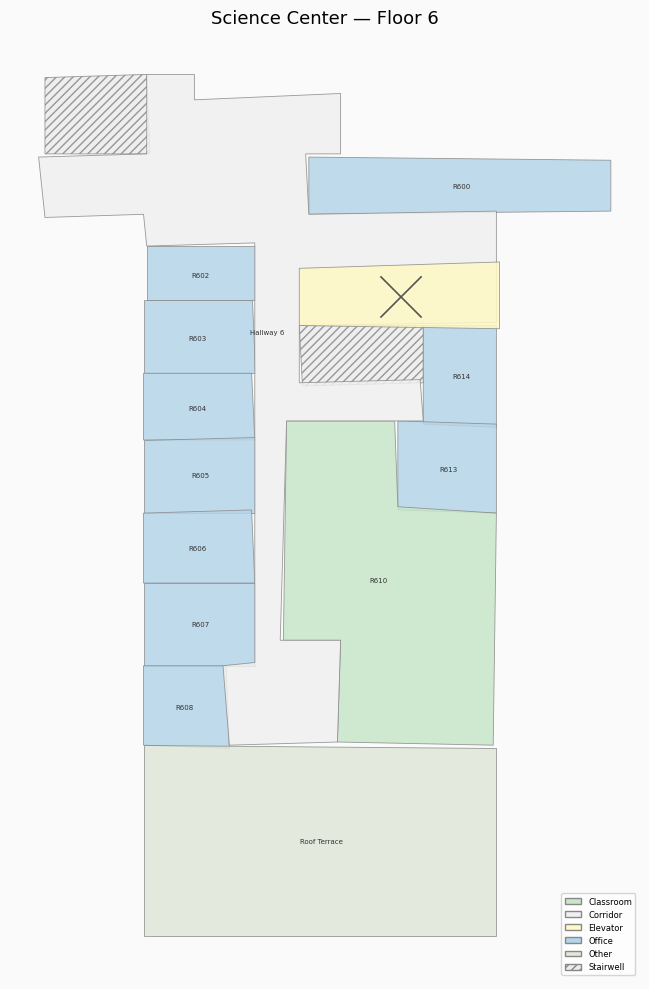

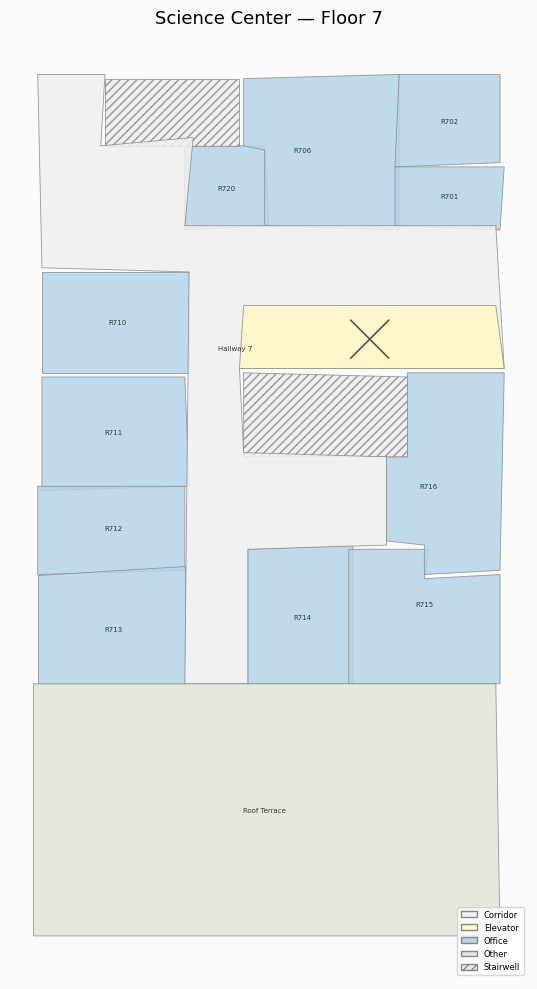

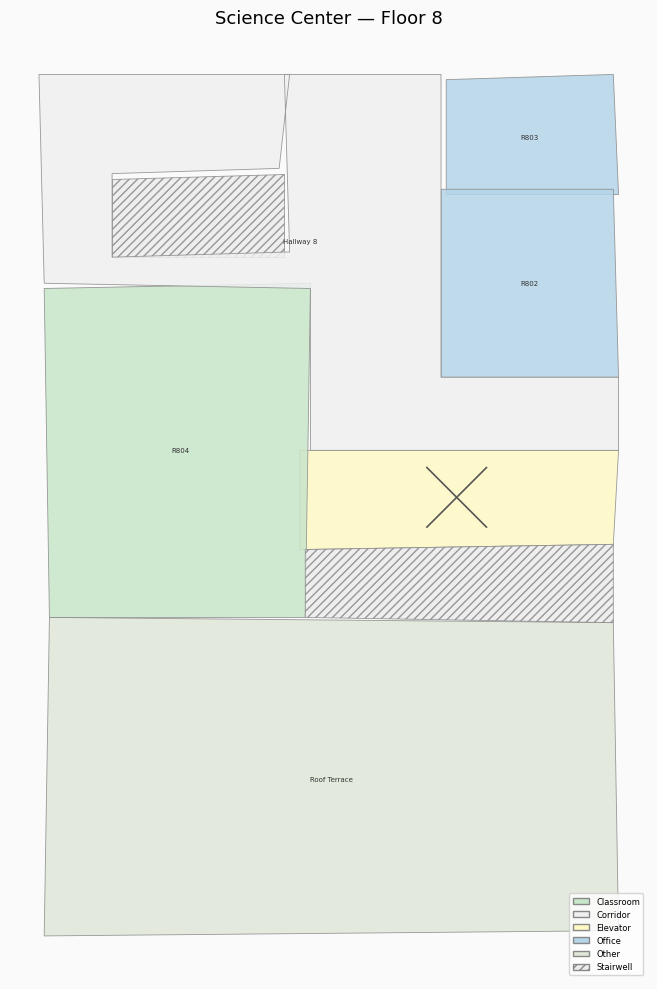

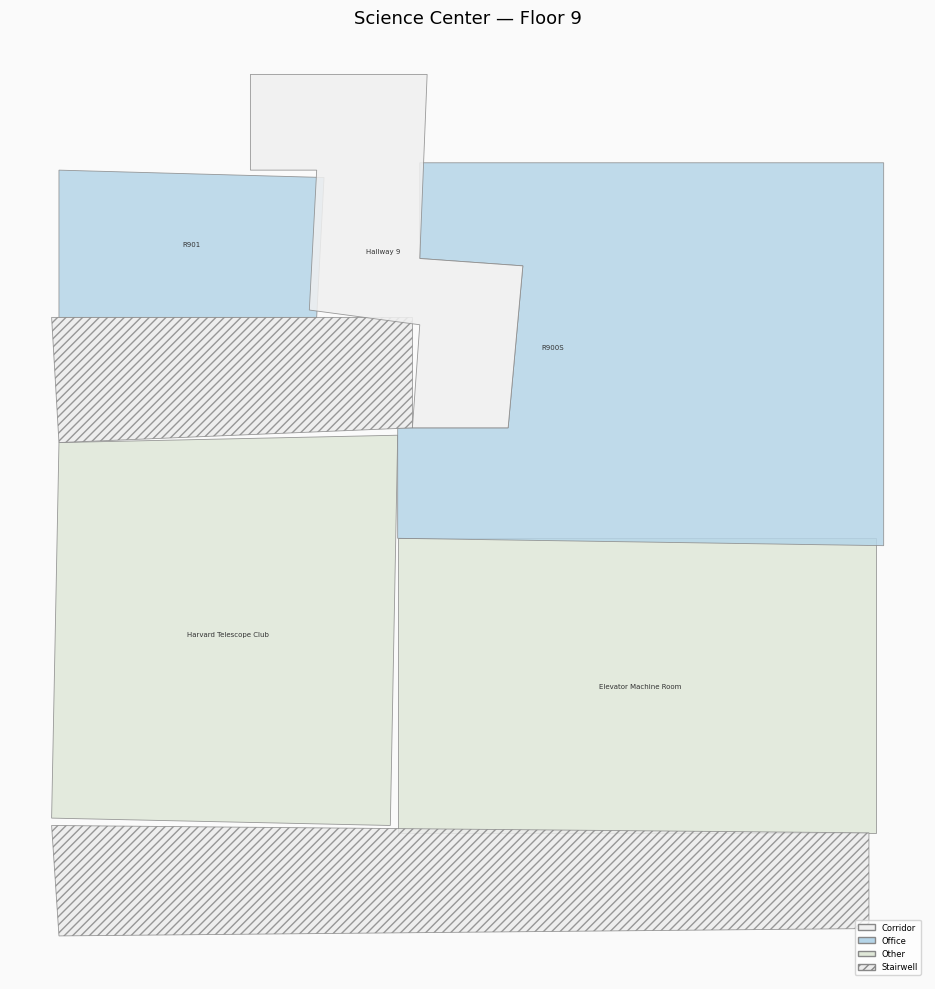

In [3]:
FLOOR_FILES = {
    1:   'Floor Plans/floor1.json',
    3:   'Floor Plans/floor3.json',
    4:   'Floor Plans/floor4 (2).json',
    5:   'Floor Plans/floor5.json',
    6:   'Floor Plans/floor6.json',
    7:   'Floor Plans/floor7.json',
    8:   'Floor Plans/floor8.json',
    9:   'Floor Plans/floor9.json',
}

all_floors = {}
for key, path in FLOOR_FILES.items():
    with open(path) as f:
        all_floors[key] = json.load(f)

for key, data in all_floors.items():
    draw_floor(data, f'Science Center — Floor {key}')

## 4 · Room-Type Statistics

A quick breakdown of room counts per type across all floors.

In [4]:
import pandas as pd

rows = []
DOOR_TYPES_SET = {'door', 'connection'}

for floor_num, data in all_floors.items():
    for room in data['rooms']:
        t = room.get('type', 'unknown')
        if t not in DOOR_TYPES_SET:
            rows.append({'Floor': floor_num, 'Type': t})

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='Type', columns='Floor', aggfunc='size', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

display(pivot.style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.0f}')
    .set_caption('Room counts by type and floor (doors excluded)')
)

Floor,1,3,4,5,6,7,8,9,Total
Type,,,,,,,,,
classroom,42,22,51,2,1,0,1,0,119
office,3,46,0,33,10,11,2,2,107
stairwell,6,6,1,4,2,2,2,2,25
other,4,2,1,1,1,1,1,2,13
corridor,3,2,2,1,1,1,1,1,12
elevator,0,1,0,1,1,1,1,0,5
entrance,5,0,0,0,0,0,0,0,5
lecture,4,0,0,0,0,0,0,0,4
library,1,1,0,0,0,0,0,0,2


## 5 · Interactive Web UI

An interactive floor plan browser is available via the **Flask server** in `app.py`.

### Features
- **Floor navigation** — up/down arrows on the left cycle through all 8 floors (1, 3–9)
- **Direct jump** — click any floor badge in the sidebar
- **Type filter** — dropdown highlights rooms of a selected type in green; all others are dimmed to grey
- **Tooltips** — hover any room to see its name and type
- **Stairwells** — rendered with diagonal hatching  
- **Elevators** — rendered with an × cross

### How to run

```bash
# From the project root:
pip install flask
python app.py
# → open http://localhost:5000 in your browser
```

---

*Notebook prepared for submission — Harvard Science Center Smart Campus project.*

## 3 · Floor-by-Floor Visualisation

Each floor is rendered individually below.  
Room labels follow the `R{number}` convention for classrooms and offices; all other room types retain their descriptive names.